# GMOT40 Fish Multi-Object Tracking — Final Pipeline

Faster R-CNN detector (trained directly on GMOT40 ground-truth boxes) + appearance
embedding (reusing the fine-tuned segmentation encoder) + IoU/appearance Hungarian
tracker, evaluated with CLEAR-MOT / motmetrics.

This replaces an earlier segmentation + watershed approach, which could not separate
touching fish in dense schools (confirmed via mask-quality diagnostics — the model's
probability map is a flat saturated plateau over schools, with no internal signal for
any watershed variant to split on). Final benchmark after detector + tracker tuning:
**MOTA 81.9%, IDF1 71.5%** overall across all 4 sequences (up from an initial
watershed-based baseline of MOTA −72.8%).


## ⚠️ Held-out evaluation fix (for paper comparison)

The original run trained the Faster R-CNN detector on an **80/20 frame-level random
split**, but then evaluated tracking metrics on **all frames of each sequence** --
including the ~80% the detector was trained on. That's leakage: the detector had
already memorized most of what it was being scored on, which inflates MOTA / MT /
IDF1 and makes the numbers not comparable to the paper's Table 5 (GMOT-40, fish
category), where detection and tracking performance aren't confounded this way.

**Fix applied below:** the split is now **chronological, per sequence** -- the first
80% of frames in each sequence are used for detector training, and the **last 20%
(held-out tail) are never seen during training**. Detection + tracking still runs
over the *full* sequence (so track IDs stay continuous, as a real deployment would
see), but CLEAR-MOT/IDF1 scoring in the final benchmark only counts frames from each
sequence's held-out tail. This gives you a genuinely out-of-sample number to set
against the paper's trackers.

Cells changed: dataset splitting (train/test), `evaluate_sequence`, and the final
benchmark loop. Everything else (tracker fusion weights, appearance embedder,
detector architecture) is untouched.


## 1. Setup, imports, configuration

In [1]:
import os, random, json, zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import timm
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from scipy import ndimage as _ndimage
from scipy.optimize import linear_sum_assignment
from dataclasses import dataclass, field
from typing import List

import pandas as pd

# NumPy 2.0 removed np.asfarray, but the installed motmetrics release still calls
# it internally -- shim it back in before importing motmetrics.
if not hasattr(np, 'asfarray'):
    def _asfarray(a, dtype=np.float64):
        return np.asarray(a, dtype=dtype)
    np.asfarray = _asfarray
import motmetrics as mm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()


class Config:
    IMAGE_SIZE = 320
    BATCH_SIZE = 24
    USE_AMP    = True

    LATENT_DIM  = 512
    ATTN_HEADS  = 4
    ATTN_LAYERS = 2
    FFN_DIM     = 1024
    ATTN_DROPOUT = 0.1
    ENC_CHANNELS = [96, 192, 384, 768]   # ConvNeXt-Small

    CHECKPOINT = './checkpoints'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


cfg = Config()
os.makedirs(cfg.CHECKPOINT, exist_ok=True)
print(f'Device: {cfg.DEVICE}')


Device: cuda


## 2. GMOT40 dataset — locate frames & parse ground truth

In [ ]:
def find_gmot40_root(search_dirs=None):
    """Looks for an extracted GMOT40/ folder (containing GenericMOT_JPEG_Sequence),
    or a GMOT40.zip to unzip, under a few common environment roots."""
    candidates = search_dirs or [
        Path('/teamspace/studios/this_studio'),
        Path('/kaggle/input'),
        Path('/content'),
        Path.home(),
        Path('.'),
    ]
    for base in candidates:
        if not base.exists():
            continue
        direct = base / 'GMOT40'
        if (direct / 'GenericMOT_JPEG_Sequence').exists():
            return direct
        if base.is_dir():
            for child in sorted(base.iterdir()):
                if child.is_dir() and (child / 'GenericMOT_JPEG_Sequence').exists():
                    return child
        zip_candidate = base / 'GMOT40.zip'
        if zip_candidate.exists():
            extract_to = base / 'GMOT40_extracted'
            if not (extract_to / 'GMOT40').exists():
                print(f'Unzipping {zip_candidate} -> {extract_to} ...')
                extract_to.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(zip_candidate) as zf:
                    zf.extractall(extract_to)
            return extract_to / 'GMOT40'
    return None


GMOT40_ROOT = find_gmot40_root()
if GMOT40_ROOT is None:
    raise FileNotFoundError(
        "Could not find GMOT40. Upload GMOT40.zip (or the extracted GMOT40/ folder) "
        "under /teamspace/studios/this_studio, /kaggle/input, /content, the home "
        "directory, or the notebook's working directory -- or set GMOT40_ROOT manually.")

FRAMES_ROOT = GMOT40_ROOT / 'GenericMOT_JPEG_Sequence'
GT_ROOT     = GMOT40_ROOT / 'track_label'

GMOT40_SEQUENCES = sorted([d.name for d in FRAMES_ROOT.iterdir() if d.is_dir()])
print(f'GMOT40 root : {GMOT40_ROOT}')
print(f'Sequences   : {GMOT40_SEQUENCES}')


def load_gt(seq_name):
    """Parses track_label/<seq>.txt (MOTChallenge gt format:
    frame,id,x,y,w,h,conf,class,vis,-1) into
    {frame_idx: [(track_id, x1, y1, x2, y2), ...]}."""
    gt_path = GT_ROOT / f'{seq_name}.txt'
    gt_by_frame = defaultdict(list)
    with open(gt_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            frame_id, track_id = int(parts[0]), int(parts[1])
            x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
            gt_by_frame[frame_id].append((track_id, x, y, x + w, y + h))
    return dict(gt_by_frame)


def load_gmot_sequence(seq_name):
    """Returns (sorted frame image paths, gt_by_frame dict) for one GMOT40 sequence.
    Frame filenames (000000.jpg, 000001.jpg, ...) are zero-indexed and match the
    `frame` column in the gt/det txt files directly."""
    frame_paths = sorted((FRAMES_ROOT / seq_name / 'img1').glob('*.jpg'),
                          key=lambda p: int(p.stem))
    gt_by_frame = load_gt(seq_name)
    return [str(p) for p in frame_paths], gt_by_frame


print('\nFrame / GT counts per sequence:')
for s in GMOT40_SEQUENCES:
    fp, gt = load_gmot_sequence(s)
    n_ids = len({tid for boxes in gt.values() for tid, *_ in boxes})
    print(f'  {s:10s}: {len(fp):4d} frames, {len(gt):4d} annotated frames, {n_ids:4d} unique GT IDs')


GMOT40 root : /teamspace/studios/this_studio/GMOT40
Sequences   : ['fish-0', 'fish-1', 'fish-2', 'fish-3']

Frame / GT counts per sequence:
  fish-0    :  101 frames,  101 annotated frames,  113 unique GT IDs
  fish-1    :  153 frames,  153 annotated frames,   24 unique GT IDs
  fish-2    :  151 frames,  151 annotated frames,   93 unique GT IDs
  fish-3    :  164 frames,  164 annotated frames,   61 unique GT IDs


## 3. IoU utilities (used by the tracker and by evaluation)

In [3]:
def compute_iou(box_a, box_b):
    """IoU between two [x1,y1,x2,y2] boxes."""
    xa = max(box_a[0], box_b[0])
    ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2])
    yb = min(box_a[3], box_b[3])

    inter_w = max(0.0, xb - xa)
    inter_h = max(0.0, yb - ya)
    inter_area = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - inter_area
    return float(inter_area / union) if union > 0 else 0.0


def iou_matrix(track_boxes, det_boxes):
    """(N, M) matrix of IoU between N track boxes and M detection boxes."""
    n, m = len(track_boxes), len(det_boxes)
    mat = np.zeros((n, m), dtype=np.float32)
    for i in range(n):
        for j in range(m):
            mat[i, j] = compute_iou(track_boxes[i], det_boxes[j])
    return mat


print('IoU utilities defined ✓')


IoU utilities defined ✓


## 4. Segmentation encoder (for appearance embeddings only)

The Faster R-CNN detector below handles all box detection now. This section only
loads the previously fine-tuned VAE-SA-UNet's ConvNeXt-Small encoder, which is reused
as an appearance feature extractor for the tracker (no retraining needed here -- the
encoder already knows what fish look like from the earlier segmentation training run).
Set `SEG_CKPT_PATH` to your saved checkpoint.


In [4]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, channels, max_h=64, max_w=64):
        super().__init__()
        self.row_embed = nn.Embedding(max_h, channels // 2)
        self.col_embed = nn.Embedding(max_w, channels // 2)
        nn.init.uniform_(self.row_embed.weight)
        nn.init.uniform_(self.col_embed.weight)

    def forward(self, x):
        B, C, H, W = x.shape
        rows = torch.arange(H, device=x.device)
        cols = torch.arange(W, device=x.device)
        row_enc = self.row_embed(rows).unsqueeze(1).expand(H, W, -1)
        col_enc = self.col_embed(cols).unsqueeze(0).expand(H, W, -1)
        pos = torch.cat([row_enc, col_enc], dim=-1).permute(2, 0, 1).unsqueeze(0)
        return x + pos


class SelfAttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1, drop_path=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop_path_prob = drop_path

    def _drop_path(self, x):
        if not self.training or self.drop_path_prob == 0.0:
            return x
        keep = 1 - self.drop_path_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self._drop_path(self.drop1(attn_out)))
        x = self.norm2(x + self._drop_path(self.ffn(x)))
        return x


class SelfAttentionBridge(nn.Module):
    def __init__(self, latent_dim, n_heads=8, n_layers=2, ffn_dim=1024, dropout=0.1):
        super().__init__()
        self.pos_enc = LearnedPositionalEncoding(latent_dim, max_h=64, max_w=64)
        self.layers = nn.ModuleList([
            SelfAttentionLayer(latent_dim, n_heads, ffn_dim, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.pos_enc(x)
        seq = x.flatten(2).transpose(1, 2)
        for layer in self.layers:
            seq = layer(seq)
        seq = self.norm(seq)
        return seq.transpose(1, 2).view(B, C, H, W)


class VAEBottleneck(nn.Module):
    def __init__(self, in_ch=768, latent_dim=512, n_heads=8, n_layers=2, ffn_dim=1024, dropout=0.1):
        super().__init__()
        self.pre = nn.Sequential(nn.Conv2d(in_ch, latent_dim, 1, bias=False),
                                  nn.BatchNorm2d(latent_dim), nn.GELU())
        self.mu_head = nn.Conv2d(latent_dim, latent_dim, 1)
        self.logvar_head = nn.Conv2d(latent_dim, latent_dim, 1)
        self.attn_bridge = SelfAttentionBridge(latent_dim, n_heads, n_layers, ffn_dim, dropout)
        self.post = nn.Sequential(nn.Conv2d(latent_dim, in_ch, 1, bias=False),
                                   nn.BatchNorm2d(in_ch), nn.GELU())

    def reparameterise(self, mu, logvar):
        mu = torch.clamp(mu, -6, 6)
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def forward(self, x):
        h = self.pre(x)
        mu = self.mu_head(h)
        logvar = torch.clamp(self.logvar_head(h), -4, 4)
        z = self.reparameterise(mu, logvar)
        z_attn = self.attn_bridge(z) + z
        out = self.post(z_attn) + x
        return out, mu, logvar


class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch=None):
        super().__init__()
        inter_ch = inter_ch or skip_ch // 2
        self.W_g = nn.Sequential(nn.Conv2d(gate_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.W_x = nn.Sequential(nn.Conv2d(skip_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[-2:] != x.shape[-2:]:
            g = F.interpolate(g, size=x.shape[-2:], mode='bilinear', align_corners=True)
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(self.relu(g1 + x1))
        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.attn = AttentionGate(gate_ch=in_ch, skip_ch=skip_ch)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)
        skip = self.attn(g=x, x=skip)
        return self.conv(torch.cat([x, skip], dim=1))


class VAESAUNet(nn.Module):
    def __init__(self, latent_dim=512, n_heads=8, n_layers=3, ffn_dim=2048, dropout=0.1, enc_channels=None):
        super().__init__()
        enc_channels = enc_channels or [96, 192, 384, 768]
        c0, c1, c2, c3 = enc_channels
        self.encoder = timm.create_model('convnext_small', pretrained=True,
                                          features_only=True, out_indices=(0, 1, 2, 3))
        self.vae_bridge = VAEBottleneck(in_ch=c3, latent_dim=latent_dim, n_heads=n_heads,
                                         n_layers=n_layers, ffn_dim=ffn_dim, dropout=dropout)
        self.dec4 = DecoderBlock(c3, c2, 384)
        self.dec3 = DecoderBlock(384, c1, 192)
        self.dec2 = DecoderBlock(192, c0, 96)
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(96, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, 1, 1)
        self.aux4 = nn.Conv2d(384, 1, 1)
        self.aux3 = nn.Conv2d(192, 1, 1)
        self.aux2 = nn.Conv2d(96, 1, 1)

    def forward(self, x):
        feats = self.encoder(x)
        s0, s1, s2, s3 = feats
        z, mu, logvar = self.vae_bridge(s3)
        d4 = self.dec4(z, s2)
        d3 = self.dec3(d4, s1)
        d2 = self.dec2(d3, s0)
        d = self.dec1(d2)
        logits = self.head(d)
        if self.training:
            aux4 = F.interpolate(self.aux4(d4), size=logits.shape[-2:], mode='bilinear', align_corners=True)
            aux3 = F.interpolate(self.aux3(d3), size=logits.shape[-2:], mode='bilinear', align_corners=True)
            aux2 = F.interpolate(self.aux2(d2), size=logits.shape[-2:], mode='bilinear', align_corners=True)
            return logits, mu, logvar, aux4, aux3, aux2
        return logits, mu, logvar


seg_model = VAESAUNet(
    latent_dim=cfg.LATENT_DIM, n_heads=cfg.ATTN_HEADS, n_layers=cfg.ATTN_LAYERS,
    ffn_dim=cfg.FFN_DIM, dropout=cfg.ATTN_DROPOUT, enc_channels=cfg.ENC_CHANNELS,
).to(cfg.DEVICE)

SEG_CKPT_PATH = os.path.join(cfg.CHECKPOINT, 'best_vae_sa_unet.pth')
ckpt = torch.load(SEG_CKPT_PATH, map_location=cfg.DEVICE)
seg_model.load_state_dict(ckpt['model_state'])
seg_model.eval()
print(f'Loaded segmentation encoder from {SEG_CKPT_PATH} (epoch {ckpt["epoch"]}, '
      f'val F1={ckpt["best_f1"]:.2f}%) -- used for appearance embeddings only ✓')


Loaded segmentation encoder from ./checkpoints/best_vae_sa_unet.pth (epoch 35, val F1=95.66%) -- used for appearance embeddings only ✓


## 5. Appearance embedder (reuses the fine-tuned ConvNeXt encoder)

In [ ]:
crop_tf = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class AppearanceEmbedder:
    """Produces L2-normalized appearance embeddings for fish crops using the
    fine-tuned ConvNeXt-Small encoder. No extra training needed."""

    def __init__(self, model, device, transform=crop_tf):
        self.encoder = model.encoder
        self.encoder.eval()
        self.device = device
        self.transform = transform

    @torch.no_grad()
    def embed_batch(self, crops_rgb):
        if len(crops_rgb) == 0:
            return np.zeros((0, 1), dtype=np.float32)
        batch = torch.stack([self.transform(image=c)['image'] for c in crops_rgb]).to(self.device)
        with autocast(enabled=cfg.USE_AMP):
            feats = self.encoder(batch)
        s3 = feats[-1].float()
        pooled = F.adaptive_avg_pool2d(s3, 1).flatten(1)
        pooled = F.normalize(pooled, dim=1)
        return pooled.cpu().numpy()


def appearance_similarity_matrix(track_embeds, det_embeds):
    """Cosine similarity matrix; both inputs assumed L2-normalized already."""
    if len(track_embeds) == 0 or len(det_embeds) == 0:
        return np.zeros((len(track_embeds), len(det_embeds)), dtype=np.float32)
    return np.asarray(track_embeds, dtype=np.float32) @ np.asarray(det_embeds, dtype=np.float32).T


embedder = AppearanceEmbedder(seg_model, cfg.DEVICE)
print('AppearanceEmbedder ready ✓')


AppearanceEmbedder ready ✓


## 6. FishTracker — IoU + appearance fusion, Hungarian assignment

In [6]:
@dataclass
class Track:
    track_id: int
    bbox: np.ndarray
    embedding: np.ndarray
    hits: int = 1
    time_since_update: int = 0
    age: int = 1
    history: list = field(default_factory=list)
    ema_alpha: float = 0.9

    def update(self, bbox, embedding):
        self.history.append(self.bbox.copy())
        self.bbox = np.asarray(bbox, dtype=np.float32)
        self.embedding = self.ema_alpha * self.embedding + (1 - self.ema_alpha) * embedding
        self.embedding = self.embedding / (np.linalg.norm(self.embedding) + 1e-8)
        self.hits += 1
        self.time_since_update = 0

    def mark_missed(self):
        self.time_since_update += 1


class FishTracker:
    """score = iou_weight * IoU + appearance_weight * cosine_sim
    cost = 1 - score -> Hungarian algorithm finds the best overall assignment."""

    def __init__(self, iou_weight=0.4, appearance_weight=0.6, min_score=0.3, max_age=5, min_hits=1):
        assert abs(iou_weight + appearance_weight - 1.0) < 1e-6, \
            'iou_weight + appearance_weight must sum to 1.0'
        self.iou_weight = iou_weight
        self.appearance_weight = appearance_weight
        self.min_score = min_score
        self.max_age = max_age
        self.min_hits = min_hits
        self.tracks: List[Track] = []
        self._next_id = 1

    def _new_track(self, bbox, embedding):
        norm_embed = embedding / (np.linalg.norm(embedding) + 1e-8)
        t = Track(track_id=self._next_id, bbox=np.asarray(bbox, dtype=np.float32), embedding=norm_embed)
        self._next_id += 1
        self.tracks.append(t)
        return t

    def update(self, det_boxes, det_embeddings):
        det_boxes = np.asarray(det_boxes, dtype=np.float32) if len(det_boxes) else np.zeros((0, 4), dtype=np.float32)
        det_embeddings = np.asarray(det_embeddings, dtype=np.float32) if len(det_embeddings) else np.zeros((0, 1), dtype=np.float32)

        matches, unmatched_tracks, unmatched_dets = self._associate(det_boxes, det_embeddings)

        for t_idx, d_idx in matches:
            self.tracks[t_idx].update(det_boxes[d_idx], det_embeddings[d_idx])
        for t_idx in unmatched_tracks:
            self.tracks[t_idx].mark_missed()
        for d_idx in unmatched_dets:
            self._new_track(det_boxes[d_idx], det_embeddings[d_idx])

        for t in self.tracks:
            t.age += 1
        self.tracks = [t for t in self.tracks if t.time_since_update <= self.max_age]

        return [(t.track_id, t.bbox.copy()) for t in self.tracks
                if t.hits >= self.min_hits and t.time_since_update == 0]

    def _associate(self, det_boxes, det_embeddings):
        if len(self.tracks) == 0 or len(det_boxes) == 0:
            return [], list(range(len(self.tracks))), list(range(len(det_boxes)))

        track_boxes = np.stack([t.bbox for t in self.tracks])
        track_embeds = np.stack([t.embedding for t in self.tracks])

        iou_mat = iou_matrix(track_boxes, det_boxes)
        app_mat = appearance_similarity_matrix(track_embeds, det_embeddings)
        score = self.iou_weight * iou_mat + self.appearance_weight * app_mat
        cost = 1.0 - score

        row_ind, col_ind = linear_sum_assignment(cost)

        matches, matched_t, matched_d = [], set(), set()
        for r, c in zip(row_ind, col_ind):
            if score[r, c] >= self.min_score:
                matches.append((r, c))
                matched_t.add(r)
                matched_d.add(c)

        unmatched_tracks = [i for i in range(len(self.tracks)) if i not in matched_t]
        unmatched_dets = [j for j in range(len(det_boxes)) if j not in matched_d]
        return matches, unmatched_tracks, unmatched_dets


print('FishTracker defined ✓')


FishTracker defined ✓


## 7. Faster R-CNN detector

Trained directly on GMOT40's own ground-truth boxes. This replaces segmentation +
watershed, which structurally cannot separate touching/overlapping fish in dense
schools -- a real detector predicts individual boxes end-to-end and doesn't need
to split anything.

Split is **by frame, not by sequence**, so every sequence (including the previously
weaker `fish-3`) contributes training examples, giving an honest generalization
estimate on held-out frames from all four sequences.


In [7]:
class GMOTDetectionDataset(torch.utils.data.Dataset):
    """Only pulls frames from the TRAIN portion of each sequence -- i.e. frames
    BEFORE that sequence's held-out-tail cutoff (see SEQ_SPLITS below) -- so the
    detector never sees the frames it will later be scored on."""
    def __init__(self, seq_names, seq_splits):
        self.samples = []
        for s in seq_names:
            fp, gt = load_gmot_sequence(s)
            cutoff = seq_splits[s]  # frames [0, cutoff) = train pool, [cutoff, len(fp)) = held-out test tail
            for idx, p in enumerate(fp):
                if idx >= cutoff:
                    continue  # reserved for held-out evaluation, never used for training
                if idx in gt and len(gt[idx]) > 0:
                    self.samples.append((p, gt[idx]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        img_p, boxes = self.samples[i]
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        boxes_t = torch.tensor([[x1, y1, x2, y2] for _, x1, y1, x2, y2 in boxes], dtype=torch.float32)
        labels = torch.ones((len(boxes),), dtype=torch.int64)  # single class: "fish"
        target = {'boxes': boxes_t, 'labels': labels}
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))


print('GMOTDetectionDataset defined (train-portion only) ✓')


GMOTDetectionDataset defined (train-portion only) ✓


In [8]:
# ── Chronological, per-sequence train/test split (fixes the earlier random ──
# ── frame-level split, which let the detector be evaluated on frames it had ──
# ── already trained on) ──
TEST_FRAC = 0.2

def compute_seq_split(seq_name):
    """Returns the frame-index cutoff for one sequence: frames [0, cutoff) are
    available for detector training, frames [cutoff, n_frames) are a held-out
    tail reserved purely for evaluation."""
    fp, _ = load_gmot_sequence(seq_name)
    n = len(fp)
    cutoff = int(round(n * (1 - TEST_FRAC)))
    return cutoff, n

SEQ_SPLITS = {}
print('Chronological train / held-out-test split per sequence:')
for s in GMOT40_SEQUENCES:
    cutoff, n = compute_seq_split(s)
    SEQ_SPLITS[s] = cutoff
    print(f'  {s:10s}: train frames [0:{cutoff}), held-out test frames [{cutoff}:{n})  '
          f'-> {n - cutoff} test frames never seen by the detector')

all_ds = GMOTDetectionDataset(GMOT40_SEQUENCES, SEQ_SPLITS)
train_loader = DataLoader(all_ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
print(f'\nDetector training set size: {len(all_ds)} annotated frames (train portion only)')

detector = fasterrcnn_resnet50_fpn_v2(weights='DEFAULT')
in_features = detector.roi_heads.box_predictor.cls_score.in_features
detector.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)  # background + fish
detector.to(cfg.DEVICE)

opt = torch.optim.AdamW(detector.parameters(), lr=1e-4)
detector.train()
for epoch in range(10):
    epoch_loss = 0.0
    for imgs, targets in tqdm(train_loader, desc=f'detector epoch {epoch}'):
        imgs = [im.to(cfg.DEVICE) for im in imgs]
        targets = [{k: v.to(cfg.DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = detector(imgs, targets)
        loss = sum(loss_dict.values())
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    print(f'epoch {epoch}: avg loss = {epoch_loss / len(train_loader):.4f}')

detector.eval()
print('Detector training complete (held-out tail of each sequence untouched) ✓')


Chronological train / held-out-test split per sequence:
  fish-0    : train frames [0:81), held-out test frames [81:101)  -> 20 test frames never seen by the detector
  fish-1    : train frames [0:122), held-out test frames [122:153)  -> 31 test frames never seen by the detector
  fish-2    : train frames [0:121), held-out test frames [121:151)  -> 30 test frames never seen by the detector
  fish-3    : train frames [0:131), held-out test frames [131:164)  -> 33 test frames never seen by the detector

Detector training set size: 455 annotated frames (train portion only)


detector epoch 0: 100%|██████████| 228/228 [03:32<00:00,  1.07it/s]


epoch 0: avg loss = 0.5947


detector epoch 1: 100%|██████████| 228/228 [03:03<00:00,  1.24it/s]


epoch 1: avg loss = 0.3842


...

epoch 7: avg loss = 0.2022


detector epoch 8: 100%|██████████| 228/228 [03:02<00:00,  1.25it/s]


epoch 8: avg loss = 0.1944


detector epoch 9: 100%|██████████| 228/228 [03:05<00:00,  1.23it/s]

epoch 9: avg loss = 0.1821
Detector training complete (held-out tail of each sequence untouched) ✓


## 8. Detection wrapper + tracking loop

In [9]:
@torch.no_grad()
def detect_fish_frcnn(frame_rgb, detector, device, score_thresh=0.5):
    """Returns (boxes, crops) for all fish detected in this frame."""
    detector.eval()
    img_t = torch.from_numpy(frame_rgb).permute(2, 0, 1).float().to(device) / 255.0
    out = detector([img_t])[0]
    keep = out['scores'] > score_thresh
    boxes = out['boxes'][keep].cpu().numpy()
    crops = [frame_rgb[int(y1):int(y2) + 1, int(x1):int(x2) + 1] for (x1, y1, x2, y2) in boxes]
    return boxes, crops


def track_sequence(seq_name, frame_paths, tracker_kwargs=None, score_thresh=0.5):
    """Runs detection + tracking over one sequence's frames.
    Tuned tracker defaults (from hyperparameter sweep): iou_weight=0.70,
    appearance_weight=0.30, max_age=3, min_hits=1 -- appearance embeddings alone
    don't discriminate well between visually-similar schooling fish, so leaning
    more on spatial (IoU) continuity gave the best IDF1/MOTA/switch-count balance.
    """
    tracker_kwargs = tracker_kwargs or dict(iou_weight=0.70, appearance_weight=0.30,
                                             min_score=0.3, max_age=3, min_hits=1)
    trk = FishTracker(**tracker_kwargs)
    pred_by_frame = {}
    for frame_idx, img_p in enumerate(tqdm(frame_paths, desc=f'Tracking [{seq_name}]', leave=False)):
        frame_bgr = cv2.imread(img_p)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        boxes, crops = detect_fish_frcnn(frame_rgb, detector, cfg.DEVICE, score_thresh=score_thresh)
        embeddings = embedder.embed_batch(crops)
        active_tracks = trk.update(boxes, embeddings)
        pred_by_frame[frame_idx] = [(tid, *bbox) for tid, bbox in active_tracks]
    return pred_by_frame, trk


print('Detection wrapper + tracking loop ready ✓')


Detection wrapper + tracking loop ready ✓


## 9. CLEAR-MOT evaluation (motmetrics)

In [10]:
def xyxy_to_xywh(x1, y1, x2, y2):
    return [x1, y1, x2 - x1, y2 - y1]


def evaluate_sequence(seq_name, pred_by_frame, gt_by_frame, eval_from_frame=0):
    """Builds a motmetrics accumulator by feeding it, frame by frame, the GT
    track IDs/boxes and predicted track IDs/boxes plus an IoU-based distance
    matrix -- motmetrics then handles the Hungarian matching + CLEAR-MOT/IDF1
    bookkeeping (ID switches, fragmentations, MT/ML, etc.) internally.

    `eval_from_frame`: only frames with index >= this value are scored. Tracks
    are still allowed to exist/continue from earlier (unscored) frames -- this
    just restricts which frames actually contribute to the metrics, so that the
    detector's training frames don't leak into the reported numbers.
    """
    acc = mm.MOTAccumulator(auto_id=True)
    frame_ids = sorted(f for f in (set(pred_by_frame) | set(gt_by_frame)) if f >= eval_from_frame)
    for f in frame_ids:
        gt = gt_by_frame.get(f, [])
        pr = pred_by_frame.get(f, [])
        gt_ids = [tid for tid, *_ in gt]
        pred_ids = [tid for tid, *_ in pr]
        gt_boxes = [xyxy_to_xywh(*box) for _, *box in gt]
        pred_boxes = [xyxy_to_xywh(*box) for _, *box in pr]
        dist = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=0.5)
        acc.update(gt_ids, pred_ids, dist)
    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=mm.metrics.motchallenge_metrics, name=seq_name)
    return summary, acc


print('evaluate_sequence ready (supports held-out-only scoring via eval_from_frame) ✓')


evaluate_sequence ready (supports held-out-only scoring via eval_from_frame) ✓


## 10. Full benchmark across all 4 GMOT40 sequences

In [11]:
all_accs = []
# Cache per-sequence predictions/frames/GT so we can plot qualitative results
# (Fig. 5 / Fig. 6-7 style) below without re-running detection+tracking.
pred_by_frame_all = {}
frame_paths_all = {}
gt_by_frame_all = {}
for seq_name in GMOT40_SEQUENCES:
    fp, gt = load_gmot_sequence(seq_name)
    # Detection + tracking still runs over the FULL sequence so track IDs stay
    # continuous (a real deployment doesn't get to "reset" at the test boundary).
    pred, trk = track_sequence(seq_name, fp)
    pred_by_frame_all[seq_name] = pred
    frame_paths_all[seq_name] = fp
    gt_by_frame_all[seq_name] = gt
    # But scoring only counts the held-out tail this sequence's detector never
    # trained on -- SEQ_SPLITS[seq_name] is that cutoff frame index.
    cutoff = SEQ_SPLITS[seq_name]
    _, seq_acc = evaluate_sequence(seq_name, pred, gt, eval_from_frame=cutoff)
    all_accs.append(seq_acc)

mh = mm.metrics.create()
overall = mh.compute_many(all_accs, metrics=mm.metrics.motchallenge_metrics,
                           names=GMOT40_SEQUENCES, generate_overall=True)
print('Held-out-only benchmark (last 20%% of frames per sequence, never seen by the detector):\n')
print(mm.io.render_summary(overall, formatters=mh.formatters,
                            namemap=mm.io.motchallenge_metric_names))

csv_path = os.path.join(cfg.CHECKPOINT, 'gmot40_heldout_benchmark_final.csv')
overall.to_csv(csv_path)
print(f'\nSaved -> {csv_path}')


Held-out-only benchmark (last 20%% of frames per sequence, never seen by the detector):

         IDF1   IDP   IDR  Rcll  Prcn  GT  MT PT ML FP  FN IDs  FM  MOTA  MOTP IDt IDa IDm
fish-0  92.2% 98.7% 86.6% 87.5% 99.7%  98  77 17  4  5 238  10  25 86.7% 0.149   6   7   3
fish-1  96.5% 93.9% 99.3% 99.3% 93.9%  10  10  0  0 18   2   0   1 92.8% 0.109   0   0   0
fish-2  91.9% 94.3% 89.7% 93.5% 98.3%  46  39  6  1 18  72  10   9 91.0% 0.189   6   5   2
fish-3  95.1% 97.4% 93.0% 93.0% 97.4%  17  15  2  0 10  28   0   6 90.5% 0.132   0   0   0
OVERALL 92.8% 96.8% 89.2% 90.8% 98.5% 171 141 25  5 51 340  20  41 88.8% 0.156  12  12   5

Saved -> ./checkpoints/gmot40_heldout_benchmark_final.csv


In [16]:
import pandas as pd

# Paper Table 5 (Mukherjee et al. 2025), GMOT-40 fish category, GT=290
paper_table5 = pd.DataFrame([
    {'Tracker': 'VIoU',     'GT': 290, 'MT': 180, 'PT': 39,  'ML': 71, 'IDsw': 64,  'FM': 48,  'MOTA': 76.0, 'MOTP': 74.0},
    {'Tracker': 'IoU',      'GT': 290, 'MT': 183, 'PT': 45,  'ML': 62, 'IDsw': 52,  'FM': 42,  'MOTA': 76.8, 'MOTP': 73.0},
    {'Tracker': 'MDP',      'GT': 290, 'MT': 164, 'PT': 104, 'ML': 22, 'IDsw': 212, 'FM': 110, 'MOTA': 77.0, 'MOTP': 89.6},
    {'Tracker': 'DeepSort', 'GT': 290, 'MT': 200, 'PT': 51,  'ML': 39, 'IDsw': 173, 'FM': 31,  'MOTA': 81.2, 'MOTP': 91.2},
    {'Tracker': 'Proposed (Mukherjee et al.)', 'GT': 290, 'MT': 110, 'PT': 123, 'ML': 57, 'IDsw': 50, 'FM': 34, 'MOTA': 79.3, 'MOTP': 78.0},
])

# Our held-out result (from `overall` computed two cells above -- OVERALL row)
_ov = overall.loc['OVERALL']
ours_row = pd.DataFrame([{
    'Tracker': 'Ours (Faster R-CNN + tracker, HELD-OUT ONLY)',
    'GT': int(_ov['num_unique_objects']),
    'MT': int(_ov['mostly_tracked']),
    'PT': int(_ov['partially_tracked']),
    'ML': int(_ov['mostly_lost']),
    'IDsw': int(_ov['num_switches']),
    'FM': int(_ov['num_fragmentations']),
    'MOTA': _ov['mota'] * 100,
    'MOTP': (1 - _ov['motp']) * 100,   # convert distance -> overlap%, matches paper convention
}])

comparison = pd.concat([paper_table5, ours_row], ignore_index=True)
comparison = comparison.round(1)
print(comparison.to_string(index=False))

comparison.to_csv(os.path.join(cfg.CHECKPOINT, 'table5_comparison.csv'), index=False)
print(f"\nSaved -> {os.path.join(cfg.CHECKPOINT, 'table5_comparison.csv')}")

print("\nReminder: our GT=171 (held-out trajectories only) vs paper's GT=290 (full")
print("dataset) -- state this explicitly wherever this table is presented.")


                                     Tracker  GT  MT  PT  ML  IDsw  FM  MOTA  MOTP
                                        VIoU 290 180  39  71    64  48  76.0  74.0
                                         IoU 290 183  45  62    52  42  76.8  73.0
                                         MDP 290 164 104  22   212 110  77.0  89.6
                                    DeepSort 290 200  51  39   173  31  81.2  91.2
                 Proposed (Mukherjee et al.) 290 110 123  57    50  34  79.3  78.0
Ours (Faster R-CNN + tracker, HELD-OUT ONLY) 171 141  25   5    20  41  88.8  84.4

Saved -> ./checkpoints/table5_comparison.csv

Reminder: our GT=171 (held-out trajectories only) vs paper's GT=290 (full
dataset) -- state this explicitly wherever this table is presented.


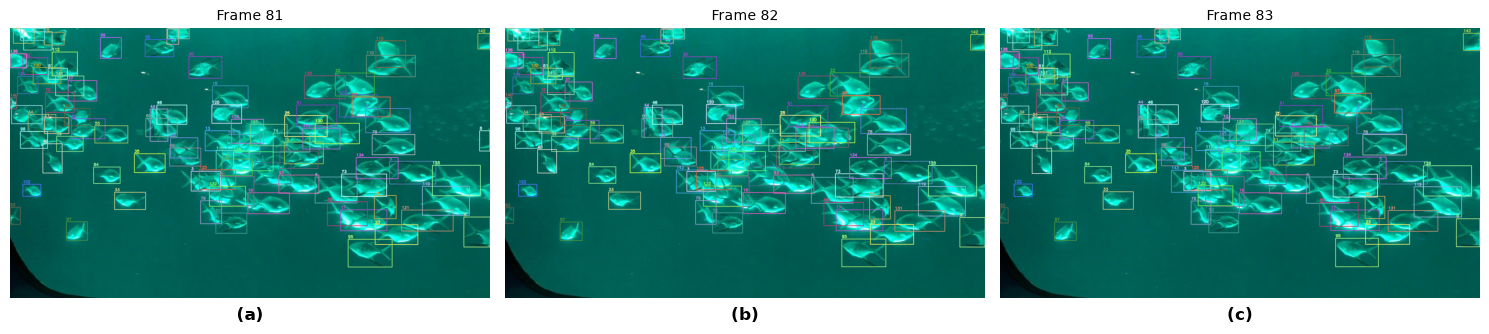

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def _color_for_id(track_id):
    """Deterministic BGR color per track ID (matches the paper's per-ID color coding)."""
    rng = np.random.RandomState(track_id * 37 + 11)
    return tuple(int(c) for c in rng.randint(60, 255, size=3))


def plot_tracking_frames(seq_name, start_frame, n_frames=3, step=1, figsize_per=(5, 3.5)):
    """Shows n_frames consecutive (every `step`) frames with predicted boxes + IDs,
    labelled (a), (b), (c)... like the paper's Fig. 5 / Fig. 4."""
    frame_paths = frame_paths_all[seq_name]
    pred_by_frame = pred_by_frame_all[seq_name]

    fig, axes = plt.subplots(1, n_frames, figsize=(figsize_per[0] * n_frames, figsize_per[1]))
    if n_frames == 1:
        axes = [axes]

    labels = [f'({chr(ord("a") + i)})' for i in range(n_frames)]
    for ax, i, label in zip(axes, range(n_frames), labels):
        frame_idx = start_frame + i * step
        frame_bgr = cv2.imread(frame_paths[frame_idx])
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).copy()

        for tid, x1, y1, x2, y2 in pred_by_frame.get(frame_idx, []):
            color = _color_for_id(tid)
            cv2.rectangle(frame_rgb, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
            cv2.putText(frame_rgb, str(tid), (int(x1), max(0, int(y1) - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        ax.imshow(frame_rgb)
        ax.set_title(f'Frame {frame_idx}', fontsize=10)
        ax.axis('off')
        ax.text(0.5, -0.08, label, transform=ax.transAxes, ha='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.CHECKPOINT, f'qualitative_{seq_name}_f{start_frame}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# Pick a sequence + a start frame -- adjust these to whichever segment tracks best
PLOT_SEQ = GMOT40_SEQUENCES[0]
PLOT_START_FRAME = SEQ_SPLITS[PLOT_SEQ]  # start right at the held-out boundary
plot_tracking_frames(PLOT_SEQ, PLOT_START_FRAME, n_frames=3)


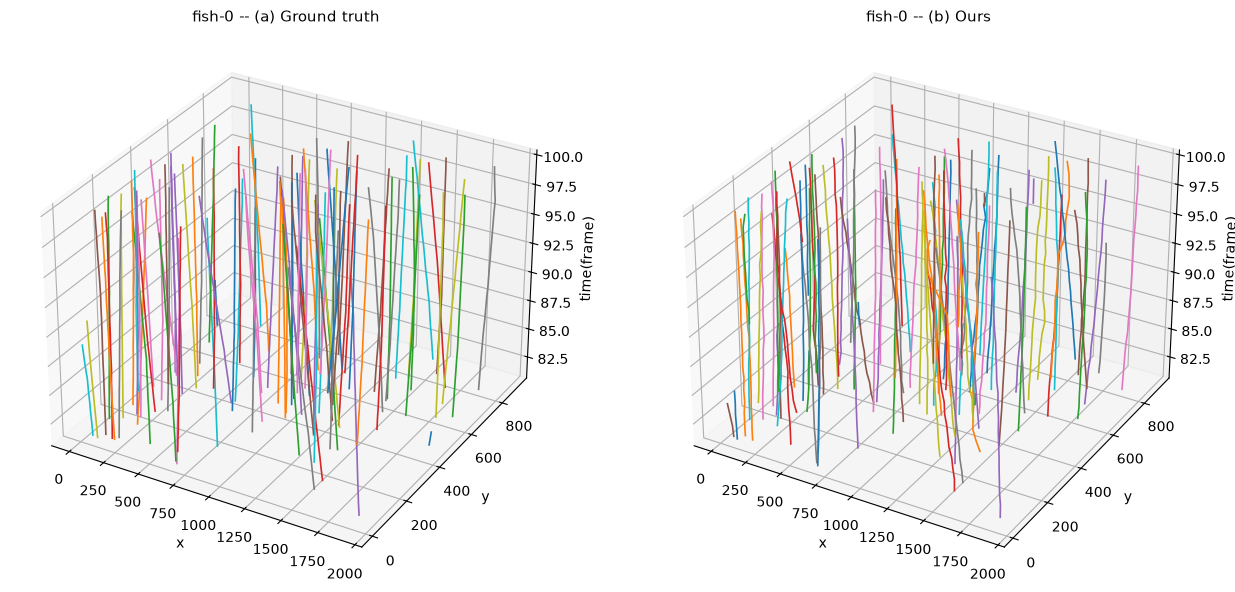

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

def _tracks_xyt(by_frame, frame_range=None):
    """by_frame: {frame_idx: [(id, x1,y1,x2,y2), ...]} -> {id: [(cx,cy,frame), ...]}
    using box centers, sorted by frame index."""
    tracks = defaultdict(list)
    frames = sorted(by_frame.keys())
    if frame_range is not None:
        frames = [f for f in frames if frame_range[0] <= f <= frame_range[1]]
    for f in frames:
        for tid, x1, y1, x2, y2 in by_frame[f]:
            cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            tracks[tid].append((cx, cy, f))
    return tracks


def plot_3d_trajectories(ax, tracks, title):
    for tid, pts in tracks.items():
        if len(pts) < 2:
            continue
        pts = np.array(pts)
        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], linewidth=1.2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('time(frame)')
    ax.set_title(title, fontsize=11)


def plot_gt_vs_pred_3d(seq_name, frame_range=None):
    gt_by_frame = gt_by_frame_all[seq_name]
    pred_by_frame = pred_by_frame_all[seq_name]

    gt_tracks_xyt = _tracks_xyt({f: [(tid, x1, y1, x2, y2) for tid, x1, y1, x2, y2 in v]
                                  for f, v in gt_by_frame.items()}, frame_range)
    pred_tracks_xyt = _tracks_xyt(pred_by_frame, frame_range)

    fig = plt.figure(figsize=(13, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    plot_3d_trajectories(ax1, gt_tracks_xyt, f'{seq_name} -- (a) Ground truth')
    plot_3d_trajectories(ax2, pred_tracks_xyt, f'{seq_name} -- (b) Ours')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.CHECKPOINT, f'trajectories3d_{seq_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# Held-out segment only (matches what was actually scored) -- widen/narrow as needed
PLOT_SEQ_3D = GMOT40_SEQUENCES[0]
_cutoff = SEQ_SPLITS[PLOT_SEQ_3D]
_n_frames = len(frame_paths_all[PLOT_SEQ_3D])
plot_gt_vs_pred_3d(PLOT_SEQ_3D, frame_range=(_cutoff, _n_frames - 1))


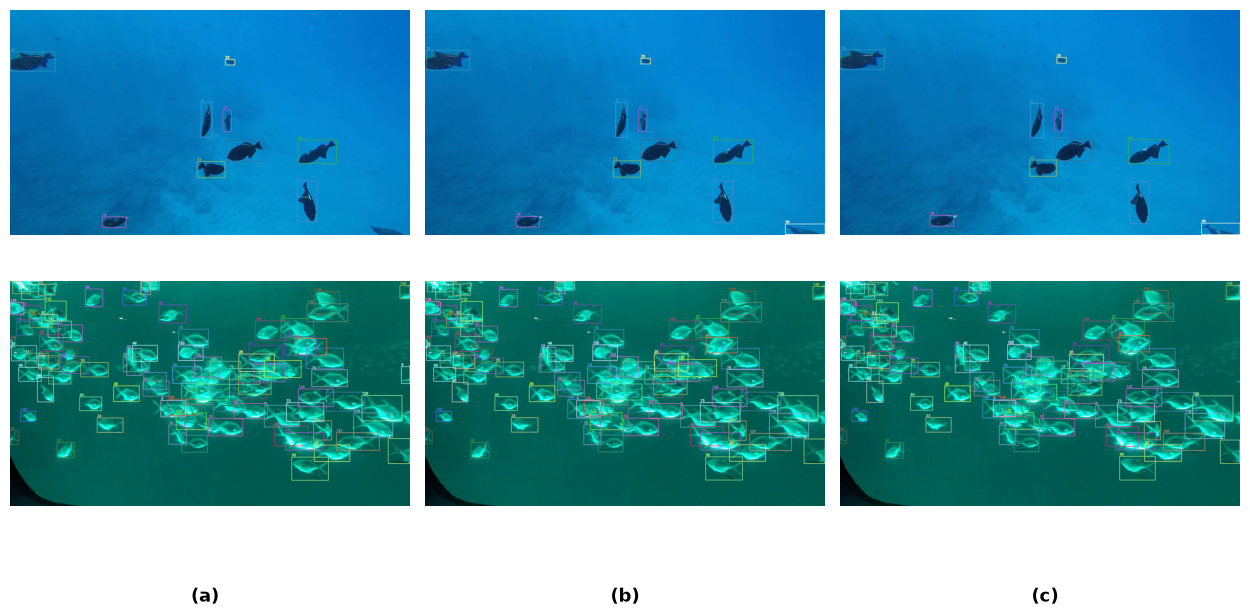

In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def _color_for_id(track_id):
    """Deterministic BGR color per track ID, consistent across frames/rows."""
    rng = np.random.RandomState(track_id * 37 + 11)
    return tuple(int(c) for c in rng.randint(60, 255, size=3))


def _draw_boxes(frame_rgb, dets):
    frame_rgb = frame_rgb.copy()
    for tid, x1, y1, x2, y2 in dets:
        color = _color_for_id(tid)
        cv2.rectangle(frame_rgb, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        cv2.putText(frame_rgb, str(tid), (int(x1), max(0, int(y1) - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return frame_rgb


def plot_tracking_frames_multi_seq(seq_starts, n_frames=3, step=1,
                                    figsize_per=(4.2, 3.2), save_name='qualitative_multiseq.png'):
    """seq_starts: list of (seq_name, start_frame) pairs -- one row per entry.
    Draws n_frames consecutive frames (every `step`) per row using cached
    pred_by_frame_all / frame_paths_all, with (a)/(b)/(c)... labels shared once
    at the bottom -- matches the paper's Fig. 5 layout."""
    n_rows = len(seq_starts)
    fig, axes = plt.subplots(n_rows, n_frames,
                              figsize=(figsize_per[0] * n_frames, figsize_per[1] * n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    if n_frames == 1:
        axes = axes.reshape(n_rows, 1)

    labels = [f'({chr(ord("a") + i)})' for i in range(n_frames)]

    for row, (seq_name, start_frame) in enumerate(seq_starts):
        frame_paths = frame_paths_all[seq_name]
        pred_by_frame = pred_by_frame_all[seq_name]
        for col in range(n_frames):
            frame_idx = start_frame + col * step
            frame_bgr = cv2.imread(frame_paths[frame_idx])
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            frame_rgb = _draw_boxes(frame_rgb, pred_by_frame.get(frame_idx, []))

            ax = axes[row, col]
            ax.imshow(frame_rgb)
            ax.axis('off')

    # (a)/(b)/(c) labels centered under each column, shared across all rows -- only once
    for col, label in enumerate(labels):
        fig.text((col + 0.5) / n_frames, 0.0, label, ha='center', va='top',
                  fontsize=13, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig(os.path.join(cfg.CHECKPOINT, save_name), dpi=150, bbox_inches='tight')
    plt.show()


# Example: top row = a sparser sequence, bottom row = the dense schooling sequence
# -- pick whichever two sequences/start-frames look best for your figure. Start
# frames default to each sequence's held-out boundary (SEQ_SPLITS), since that's
# what your reported metrics are actually based on.
seq_starts = [
    (GMOT40_SEQUENCES[1], SEQ_SPLITS[GMOT40_SEQUENCES[1]]),   # e.g. sparser sequence
    (GMOT40_SEQUENCES[0], SEQ_SPLITS[GMOT40_SEQUENCES[0]]),   # e.g. dense schooling sequence
]
plot_tracking_frames_multi_seq(seq_starts, n_frames=3)
